# Setup

In [67]:
import sys
import os
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns; sns.set(color_codes=True)
import matplotlib.pyplot as plt
from scipy import stats
# Import Scimap
import scimap as sm


# Load AnnData Files 

In [68]:
base_dir = '/path/to/base_dir/'

In [69]:
adata_cells = ad.read_h5ad(os.path.join(base_dir, "cycif_cell_anndata.h5ad"))
adata_nuclei = ad.read_h5ad(os.path.join(base_dir, "cycif_nuclei_anndata.h5ad"))


In [70]:
adata_cells

AnnData object with n_obs × n_vars = 841467 × 12
    obs: 'cell_id', 'data_type', 'match_distance', 'Eccentricity', 'Solidity', 'MajorAxisLength', 'Area', 'Orientation', 'Extent', 'CellID', 'MinorAxisLength', 'x', 'y'
    var: 'protein_name', 'full_name', 'protein_type'
    uns: 'alignment_method', 'data_source'
    obsm: 'spatial'

In [71]:
adata_cells.obs["imageid"] = "imageid_name"
adata_nuclei.obs["imageid"] = "imageid_name"

In [72]:
####Define gating and phenotyping csv files and pheno_label
os.chdir(base_dir)
gates_file = 'gates.csv'
phenotyping_workflow = 'phenotyping.csv'
pheno_label = 'Phenotype'

####gating for all markers
manual_gate = pd.read_csv(gates_file)
manual_gate = manual_gate.rename(columns={"Gates": "markers"})

# Convert marker names to string
manual_gate["markers"] = manual_gate["markers"].astype(str)

manual_gate

,markers,BDBAT0245
0,HSV,9.00
1,VSVg,8.50
2,V5,9.16
3,PanCK,8.23
4,Ollas,9.00
5,C,9.00
6,CD68,7.62
7,CD45,7.65
8,S,8.24
9,Foxp3,7.40


In [73]:
adata_cells = sm.pp.rescale (adata_cells, gate=manual_gate)

/Users/bhavyasingh/miniconda3/envs/scimap/lib/python3.10/site-packages/scimap/preprocessing/rescale.py:145: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Running GMM for image: BDBAT0245
Applying GMM to markers: Ollas, CD8a

Scaling Image: BDBAT0245
Scaling HSV (gate: 9.000)
Scaling VSVg (gate: 8.500)
Scaling V5 (gate: 9.160)
Scaling PanCK (gate: 8.230)
Scaling Ollas (gate: 9.365)
Scaling C (gate: 9.000)
Scaling CD68 (gate: 7.620)
Scaling CD45 (gate: 7.650)
Scaling S (gate: 8.240)
Scaling Foxp3 (gate: 7.400)
Scaling CD4 (gate: 7.600)
Scaling CD8a (gate: 8.139)


In [74]:
#### Phenotyping by scimap for all markers
phenotyping_workflow = "phenotyping.csv"
phenotype = pd.read_csv(phenotyping_workflow)
phenotype.columns = phenotype.columns.str.strip()
#phenotype = phenotype.rename(columns={phenotype.columns[0]: "phenotype"})
phenotype

,Unnamed: 0,Unnamed: 1,CD45,PanCK,CD8a,Foxp3,CD4,CD68
0,all,Immune,pos,NaN,NaN,NaN,NaN,NaN
1,all,Epithelial,neg,pos,NaN,NaN,NaN,NaN
2,Immune,CD8 T cells,NaN,NaN,pos,NaN,neg,NaN
3,Immune,CD4 T cells,NaN,NaN,neg,NaN,pos,NaN
4,CD4 T cells,Tregs,NaN,NaN,NaN,pos,NaN,NaN
5,CD8 T cells,Exhausted CD8,NaN,NaN,NaN,pos,NaN,NaN
6,Immune,Myeloid,NaN,NaN,NaN,NaN,NaN,pos


In [75]:
pheno_label

'Phenotype'

In [76]:
adata_cells = sm.tl.phenotype_cells (adata_cells, phenotype=phenotype, label=pheno_label)

Phenotyping Immune
Phenotyping Epithelial
-- Subsetting Immune
Phenotyping CD8 T cells
Phenotyping CD4 T cells
Phenotyping Myeloid
-- Subsetting CD4 T cells
Phenotyping Tregs
-- Subsetting CD8 T cells
Phenotyping Exhausted CD8
Consolidating the phenotypes across all groups


/Users/bhavyasingh/miniconda3/envs/scimap/lib/python3.10/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [77]:
adata_cells.obs

,cell_id,data_type,match_distance,Eccentricity,Solidity,MajorAxisLength,Area,Orientation,Extent,CellID,MinorAxisLength,x,y,imageid,Phenotype
index_right,,,,,,,,,,,,,,,
aaaaakmp-1,aaaaakmp-1,cells,0.000000,0.532761,0.889128,9.239792,52.5,0.194728,0.676190,1.208720e+06,7.394007,958.353178,1894.690494,BDBAT0245,CD4 T cells
aaaabfpk-1,aaaabfpk-1,cells,0.031297,0.725308,0.930006,10.649834,58.0,-0.343453,0.628860,1.208785e+06,7.218797,956.271595,1929.507527,BDBAT0245,Tregs
aaaabmde-1,aaaabmde-1,cells,0.000000,0.834199,0.894737,16.977566,119.0,-0.246717,0.676136,1.208540e+06,9.362511,962.131142,1903.564643,BDBAT0245,Tregs
aaaagmle-1,aaaagmle-1,cells,0.000000,0.754994,0.922677,11.201065,64.0,0.759643,0.719792,1.208616e+06,7.356336,961.495784,1898.240218,BDBAT0245,Tregs
aaaahogc-1,aaaahogc-1,cells,0.000000,0.819421,0.723618,20.294309,144.0,0.651812,0.400000,1.206753e+06,11.632548,1017.830747,2030.934754,BDBAT0245,Myeloid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimhfgnl-1,oimhfgnl-1,cells,0.266035,0.871567,0.915663,24.522506,228.0,0.396411,0.647727,7.728980e+05,12.022794,2981.108965,10361.224733,BDBAT0245,Epithelial
oimhijei-1,oimhijei-1,cells,1.331654,0.528858,0.939394,15.311156,155.0,-0.408387,0.738095,7.728370e+05,12.994732,2987.208055,10388.208760,BDBAT0245,CD4 T cells
oimhjbde-1,oimhjbde-1,cells,1.906551,0.620552,0.917910,14.152859,123.0,-1.435683,0.745455,7.723120e+05,11.098182,3011.254642,10931.812998,BDBAT0245,Unknown


In [78]:
adata_cells.obs["Phenotype"].value_counts()
# Count the occurrences
counts = adata_cells.obs["Phenotype"].value_counts()
print(counts.sum())

# Compute percentages
percentages = counts / counts.sum() * 100

# Print just Epithelial vs Unknown
print("Counts:")
print(counts[["Epithelial", "CD8 T cells", "CD4 T cells", "Tregs", "Exhausted CD8", "Myeloid"]])

print("\nPercentages:")
print(percentages[["Epithelial", "CD8 T cells", "CD4 T cells", "Tregs", "Exhausted CD8", "Myeloid"]].round(2))


841467
Counts:
Phenotype
Epithelial       475893
CD8 T cells       87186
CD4 T cells       63309
Tregs             12006
Exhausted CD8      5812
Myeloid           77059
Name: count, dtype: int64

Percentages:
Phenotype
Epithelial       56.56
CD8 T cells      10.36
CD4 T cells       7.52
Tregs             1.43
Exhausted CD8     0.69
Myeloid           9.16
Name: count, dtype: float64


In [79]:
adata_nuclei = sm.pp.rescale (adata_nuclei, gate=manual_gate)

/Users/bhavyasingh/miniconda3/envs/scimap/lib/python3.10/site-packages/scimap/preprocessing/rescale.py:145: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Running GMM for image: BDBAT0245
Applying GMM to markers: Ollas, CD8a

Scaling Image: BDBAT0245
Scaling HSV (gate: 9.000)
Scaling VSVg (gate: 8.500)
Scaling V5 (gate: 9.160)
Scaling PanCK (gate: 8.230)
Scaling Ollas (gate: 9.439)
Scaling C (gate: 9.000)
Scaling CD68 (gate: 7.620)
Scaling CD45 (gate: 7.650)
Scaling S (gate: 8.240)
Scaling Foxp3 (gate: 7.400)
Scaling CD4 (gate: 7.600)
Scaling CD8a (gate: 8.154)


In [80]:
adata_nuclei = sm.tl.phenotype_cells (adata_nuclei, phenotype=phenotype, label=pheno_label)

Phenotyping Immune
Phenotyping Epithelial
-- Subsetting Immune
Phenotyping CD8 T cells
Phenotyping CD4 T cells
Phenotyping Myeloid
-- Subsetting CD4 T cells
Phenotyping Tregs
-- Subsetting CD8 T cells
Phenotyping Exhausted CD8
Consolidating the phenotypes across all groups


/Users/bhavyasingh/miniconda3/envs/scimap/lib/python3.10/site-packages/scimap/tools/phenotype_cells.py:290: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [81]:
adata_nuclei.obs

,cell_id,data_type,match_distance,Eccentricity,Solidity,MajorAxisLength,Area,Orientation,Extent,CellID,MinorAxisLength,x,y,imageid,Phenotype
index_right,,,,,,,,,,,,,,,
aaaaakmp-1,aaaaakmp-1,nuclei,0.000000,0.710881,0.909722,5.945425,19.000000,0.151266,0.725000,1.208720e+06,4.154560,958.899956,1894.854182,BDBAT0245,CD4 T cells
aaaabfpk-1,aaaabfpk-1,nuclei,0.000000,0.556901,0.968992,7.188342,31.666667,-0.400785,0.687847,1.208785e+06,5.715100,956.161990,1929.064930,BDBAT0245,Tregs
aaaabmde-1,aaaabmde-1,nuclei,0.000000,0.770587,0.921875,11.044753,59.000000,-0.297451,0.595960,1.208540e+06,7.039200,961.759573,1903.072380,BDBAT0245,Tregs
aaaagmle-1,aaaagmle-1,nuclei,0.000000,0.701440,0.913745,8.004896,35.500000,0.898068,0.714286,1.208616e+06,5.675776,961.376396,1897.994191,BDBAT0245,Tregs
aaaahogc-1,aaaahogc-1,nuclei,0.000000,0.781027,0.668831,17.062236,103.000000,0.724953,0.356401,1.206753e+06,10.655317,1018.280145,2030.289535,BDBAT0245,Myeloid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimhfakp-1,oimhfakp-1,nuclei,0.004923,0.626962,0.978723,8.691270,46.000000,1.124061,0.821429,7.718040e+05,6.770936,3040.927093,10529.673812,BDBAT0245,Tregs
oimhfgnl-1,oimhfgnl-1,nuclei,0.122623,0.902509,0.911290,18.356681,113.000000,0.391376,0.604278,7.728980e+05,7.905676,2981.252377,10361.674557,BDBAT0245,Epithelial
oimhijei-1,oimhijei-1,nuclei,1.504841,0.727012,0.937500,10.635300,60.000000,-0.259499,0.750000,7.728370e+05,7.302462,2987.051499,10388.120406,BDBAT0245,CD4 T cells


In [82]:
adata_nuclei.obs["Phenotype"].value_counts()
# Count the occurrences
counts = adata_nuclei.obs["Phenotype"].value_counts()
print(counts.sum())

# Compute percentages
percentages = counts / counts.sum() * 100

# Print just Epithelial vs Unknown
print("Counts:")
print(counts[["Epithelial", "CD8 T cells", "CD4 T cells", "Tregs", "Exhausted CD8", "Myeloid"]])

print("\nPercentages:")
print(percentages[["Epithelial", "CD8 T cells", "CD4 T cells", "Tregs", "Exhausted CD8", "Myeloid"]].round(2))


825765
Counts:
Phenotype
Epithelial       464589
CD8 T cells       82214
CD4 T cells       64987
Tregs             15825
Exhausted CD8      7165
Myeloid           70792
Name: count, dtype: int64

Percentages:
Phenotype
Epithelial       56.26
CD8 T cells       9.96
CD4 T cells       7.87
Tregs             1.92
Exhausted CD8     0.87
Myeloid           8.57
Name: count, dtype: float64


In [83]:
# Step 1: Subset cells where Epithelial == "Epithelial" (i.e., non-immune)
non_immune_cells = adata_cells[adata_cells.obs["Phenotype"] == "Epithelial"]
non_immune_indices = non_immune_cells.obs.index

In [85]:
# Step 2: Subset the nuclei AnnData using those cell IDs
adata_nuc_filtered = adata_nuclei[adata_nuclei.obs.index.isin(non_immune_indices)].copy()


In [86]:
adata_nuc_filtered.obs

,cell_id,data_type,match_distance,Eccentricity,Solidity,MajorAxisLength,Area,Orientation,Extent,CellID,MinorAxisLength,x,y,imageid,Phenotype
index_right,,,,,,,,,,,,,,,
aaaemadp-1,aaaemadp-1,nuclei,0.000000,0.789469,0.934211,12.252169,71.0,0.475597,0.657407,1201433.0,7.520270,1253.674264,2230.275037,BDBAT0245,Epithelial
aaafmbll-1,aaafmbll-1,nuclei,0.000000,0.671399,0.915888,13.060135,98.0,-1.233659,0.685315,1203242.0,9.678813,1167.210875,2308.495895,BDBAT0245,Epithelial
aaafpebp-1,aaafpebp-1,nuclei,0.000000,0.477531,0.847527,9.789506,61.5,0.723285,0.623737,1201864.0,8.421624,1232.007428,2334.321552,BDBAT0245,Epithelial
aaahdkjm-1,aaahdkjm-1,nuclei,0.000000,0.641862,0.910569,13.794317,112.0,-1.178506,0.666667,1202122.0,10.577760,1219.854904,2170.400387,BDBAT0245,Epithelial
aaajlelo-1,aaajlelo-1,nuclei,0.000000,0.448788,0.924300,9.541391,65.0,-0.250532,0.653409,1202324.5,8.443936,1211.956052,2090.327867,BDBAT0245,Epithelial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimgeiii-1,oimgeiii-1,nuclei,0.365510,0.789175,0.792453,13.780355,84.0,0.839958,0.583333,768135.0,8.463460,3225.047635,9997.549758,BDBAT0245,Epithelial
oimgigmf-1,oimgigmf-1,nuclei,0.000000,0.391397,0.894737,6.888753,34.0,-0.585952,0.693878,765157.0,6.339182,3378.230062,10642.981225,BDBAT0245,Epithelial
oimheipl-1,oimheipl-1,nuclei,2.160185,0.866208,0.978261,10.653187,45.0,-0.029896,0.900000,773067.0,5.323228,2974.424310,10302.635020,BDBAT0245,Epithelial


In [87]:
delta = 0.01
nuclear_markers = ['HSV', 'VSVg', 'V5', 'Ollas', 'S', 'C']
cell_markers = ['PanCK', 'CD68', 'CD45', 'Foxp3', 'CD4', 'CD8a']
ProCode_list = ['HSV', 'VSVg', 'V5', 'Ollas', 'S', 'C']
#Robust Scaler metrics:
lower_percentile = 0.05
upper_percentile = 0.95
image_list = ['BDBAT0245']

In [88]:
corrections_df = pd.read_csv('background_correction.csv')
corrections_df

,Gates,HSV,VSVg,V5,Ollas,C,S
0,BDBAT0245,3700,2900,4000,2500,2000,2900


In [89]:
import numpy as np
corrections_dict = {}
for imageid in image_list:
    index = image_list.index(imageid)
    corrections = corrections_df.iloc[index, 1:(len(ProCode_list)+1)].to_list()
    corrections_dict[imageid] = np.log1p(corrections)

In [90]:
corrections_dict

{'BDBAT0245': array([8.21635833, 7.97281078, 8.29429961, 7.82444593, 7.60140233,
        7.97281078])}

In [91]:
import pandas as pd
from collections import defaultdict

# Load the guide file
gene_code = pd.read_csv("gene_procode_guide_smap.csv", encoding="cp1252")

# Fix first column name
first_col = gene_code.columns[0]
gene_code = gene_code.rename(columns={first_col: "Gene"})

# Function to normalize individual marker names
def normalize_marker(marker):
    marker = marker.strip().replace("-", "")  # Remove dashes
    if marker.upper() == "VSVG":
        return "VSVg"  # Fix case/format
    return marker

# Build the dictionary
Gene_procode_dict = defaultdict(list)

for idx, row in gene_code.iterrows():
    gene = row["Gene"]
    markers = row[1:].dropna().astype(str).map(normalize_marker).tolist()
    markers = sorted(markers)  # Optional: sort for standardization
    procode = ".".join(markers)
    Gene_procode_dict[gene].append(procode)

from itertools import permutations
from collections import defaultdict

expanded_gene_dict = defaultdict(list)

for gene, combos in Gene_procode_dict.items():
    for combo in combos:
        pcs = combo.upper().replace("-", "").split(".")
        pcs = ["VSVg" if p in ["VSVG", "VSV-G"] else p for p in pcs]
        perms = permutations(pcs)
        for p in perms:
            expanded_combo = ".".join(p)
            expanded_gene_dict[gene].append(expanded_combo)

Gene_procode_dict = expanded_gene_dict
Gene_procode_dict

defaultdict(list,
            {'F8': ['C.HSV.OLLAS',
              'C.OLLAS.HSV',
              'HSV.C.OLLAS',
              'HSV.OLLAS.C',
              'OLLAS.C.HSV',
              'OLLAS.HSV.C'],
             'Unknown': ['C.HSV.S',
              'C.S.HSV',
              'HSV.C.S',
              'HSV.S.C',
              'S.C.HSV',
              'S.HSV.C',
              'C.HSV.VSVg',
              'C.VSVg.HSV',
              'HSV.C.VSVg',
              'HSV.VSVg.C',
              'VSVg.C.HSV',
              'VSVg.HSV.C',
              'C.HSV.V5',
              'C.V5.HSV',
              'HSV.C.V5',
              'HSV.V5.C',
              'V5.C.HSV',
              'V5.HSV.C',
              'C.S.VSVg',
              'C.VSVg.S',
              'S.C.VSVg',
              'S.VSVg.C',
              'VSVg.C.S',
              'VSVg.S.C',
              'C.S.V5',
              'C.V5.S',
              'S.C.V5',
              'S.V5.C',
              'V5.C.S',
              'V5.S.C',
              'C

In [92]:
# Apply background correction using log1p-subtracted values
procode_markers = ProCode_list  # ["HSV", "VSV-G", ...]

import numpy as np

# Ensure dense matrix (if originally sparse)
if not isinstance(adata_nuc_filtered.X, np.ndarray):
    adata_nuc_filtered.X = adata_nuc_filtered.X.toarray()

# Subtract background
for marker, bg_value in zip(procode_markers, corrections_dict[image_list[0]]):
    if marker in adata_nuc_filtered.var_names:
        col_idx = list(adata_nuc_filtered.var_names).index(marker)
        adata_nuc_filtered.X[:, col_idx] = adata_nuc_filtered.X[:, col_idx] - bg_value

# Clip negatives to zero
adata_nuc_filtered.X = np.clip(adata_nuc_filtered.X, a_min=0, a_max=None)


# Prepare log-transformed matrix

In [93]:
df = pd.DataFrame(np.log1p(adata_nuc_filtered.raw.X))
df.index = adata_nuc_filtered.obs.index
df.columns = adata_nuc_filtered.var_names.to_list()

# Only keep the ProCode markers
df = df[ProCode_list]

# Attach image ID for per-slide correction
df["imageid"] = adata_nuc_filtered.obs["imageid"].values


# Apply background correction

In [94]:
df_corr_list = []

for imageid in image_list:
    df_i = df[df["imageid"] == imageid].copy()
    df_i[ProCode_list] -= corrections_dict[imageid]  # subtract background
    df_corr_list.append(df_i)

df_corr = pd.concat(df_corr_list)
df_corr.reset_index(drop=False, inplace=True)  # optional


# Plot pre/post correction histograms

In [95]:
plot_dir = os.path.join(base_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

for PC in ProCode_list:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(df[PC], ax=axes[0], kde=True)
    axes[0].set_title(f"Before Scaling: {PC}")

    sns.histplot(df_corr[PC], ax=axes[1], kde=True)
    axes[1].set_title(f"After Background Correction: {PC}")

    plt.savefig(os.path.join(plot_dir, f'{PC}_back_corr_plot.png'))
    plt.close()


In [96]:
for marker in ProCode_list:
    print(marker)
    print("Before correction:", df[marker].describe())
    print("After correction:", df_corr[marker].describe())
    print("-" * 40)

HSV
Before correction: count    460937.000000
mean          9.104899
std           0.711063
min           6.879108
25%           8.540424
50%           8.834624
75%           9.575880
max          11.090355
Name: HSV, dtype: float64
After correction: count    460937.000000
mean          0.888541
std           0.711063
min          -1.337250
25%           0.324066
50%           0.618265
75%           1.359521
max           2.873997
Name: HSV, dtype: float64
----------------------------------------
VSVg
Before correction: count    460937.000000
mean          8.096020
std           0.448316
min           5.921213
25%           7.793026
50%           7.947200
75%           8.281305
max          10.841903
Name: VSVg, dtype: float64
After correction: count    460937.000000
mean          0.123209
std           0.448316
min          -2.051598
25%          -0.179785
50%          -0.025611
75%           0.308495
max           2.869093
Name: VSVg, dtype: float64
----------------------------------

# Robust scaling (per slide)

In [97]:
df_corr_before_scaling = df_corr.copy()
iqr_values = {}

for imageid in image_list:
    subset = df_corr[df_corr["imageid"] == imageid]
    stats = subset[ProCode_list]

    median = stats.median()
    lower = stats.quantile(lower_percentile)
    upper = stats.quantile(upper_percentile)
    iqr = upper - lower
    iqr = iqr.replace(0, 1e-8)  # avoid division by zero

    iqr_values[imageid] = iqr

    df_corr.loc[df_corr["imageid"] == imageid, ProCode_list] = (
        stats - median
    ) / iqr


In [98]:
for PC in ProCode_list:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(df_corr_before_scaling[PC], ax=axes[0], kde=True, bins=50)
    axes[0].set_title(f'Before Scaling: {PC}')

    sns.histplot(df_corr[PC], ax=axes[1], kde=True, bins=50)
    axes[1].set_title(f'After Scaling: {PC}')

    plt.savefig(os.path.join(plot_dir, f'{PC}_Robust_Scaler_plot.png'))
    plt.close()


# Compute delta_value per cell

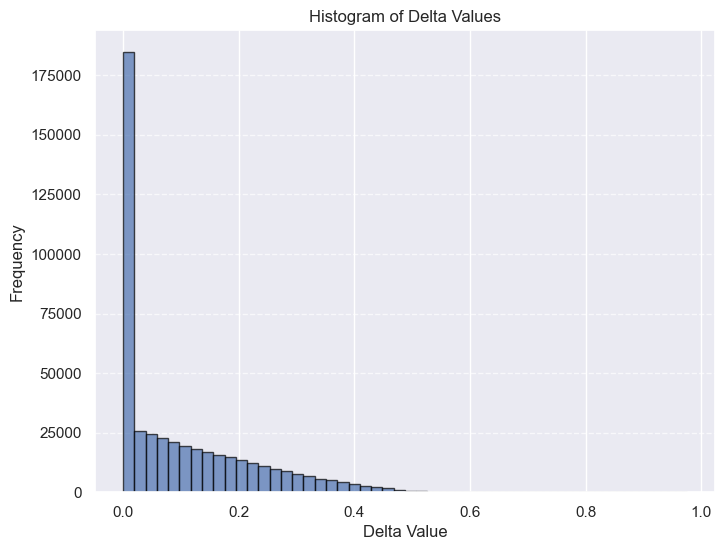

In [99]:
sorted_vals = np.sort(df_corr[ProCode_list].values, axis=1)
df_corr["delta_value"] = np.where(
    (sorted_vals.shape[1] >= 4) &
    (sorted_vals[:, -3] > 0) &
    (sorted_vals[:, -2] > 0) &
    (sorted_vals[:, -1] > 0),
    sorted_vals[:, -3] - sorted_vals[:, -4],
    0
)

plt.figure(figsize=(8, 6))
plt.hist(df_corr["delta_value"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Delta Value")
plt.ylabel("Frequency")
plt.title("Histogram of Delta Values")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


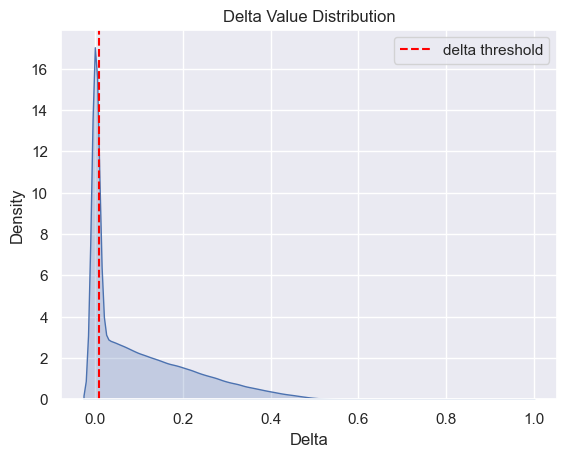

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df_corr["delta_value"], fill=True)
plt.axvline(0.01, color="red", linestyle="--", label="delta threshold")
plt.title("Delta Value Distribution")
plt.xlabel("Delta")
plt.ylabel("Density")
plt.legend()
plt.show()


In [101]:
sorted_values = np.sort(df_corr[ProCode_list].values, axis=1)
delta_value = sorted_values[:, -3] - sorted_values[:, -4]

qualify_by_signal = (
    (sorted_values[:, -1] > 0) &
    (sorted_values[:, -2] > 0) &
    (sorted_values[:, -3] > 0)
)

delta_pass = df_corr["delta_value"] > 0.01

print("Have 3+ markers > 0:", qualify_by_signal.sum())
print("Pass delta > 0.01:", delta_pass.sum())
print("Lost to delta filter:", qualify_by_signal.sum() - delta_pass.sum())


Have 3+ markers > 0: 303489
Pass delta > 0.01: 289448
Lost to delta filter: 14041


Delta threshold: 0.01


<Axes: >

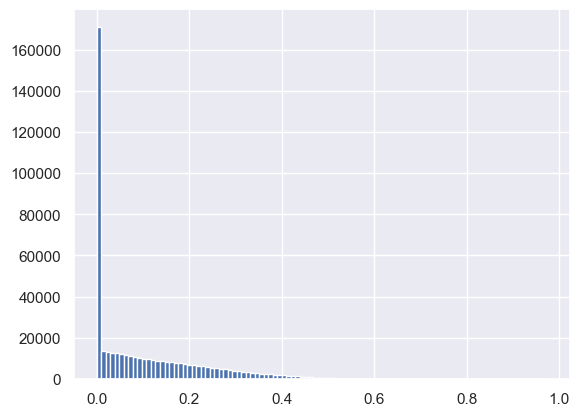

In [102]:
# What threshold are you using?
print("Delta threshold:", delta)

# What's the distribution?
df_corr["delta_value"].hist(bins=100)

# Assign ProCodes where delta > threshold

In [103]:
df_tumor = df_corr[df_corr["delta_value"] > delta].copy()
df_tumor["Pro-Code"] = ""

for i in df_tumor.index:
    top_epitopes = df_corr.loc[i, ProCode_list].sort_values(ascending=False)
    top3 = sorted(top_epitopes.index[:3])  # top 3 markers, sorted
    procode = ".".join(top3)
    df_tumor.loc[i, "Pro-Code"] = procode

In [104]:
df_tumor

,index_right,HSV,VSVg,V5,Ollas,S,C,imageid,delta_value,Pro-Code
0,aaaemadp-1,0.254525,0.200559,0.174611,-0.160959,0.447768,-0.210125,BDBAT0245,0.025948,HSV.S.VSVg
2,aaafpebp-1,-0.064664,0.661005,0.609473,-0.477305,0.644264,-0.091035,BDBAT0245,0.674137,S.V5.VSVg
3,aaahdkjm-1,0.157071,0.455433,0.401713,-0.227036,0.479136,0.184876,BDBAT0245,0.216837,S.V5.VSVg
4,aaajlelo-1,-0.102432,0.467173,0.391209,-0.539022,0.432039,-0.090049,BDBAT0245,0.481258,S.V5.VSVg
5,aaajllaa-1,-0.119473,0.393443,0.324618,-0.607109,0.385769,-0.207342,BDBAT0245,0.444092,S.V5.VSVg
...,...,...,...,...,...,...,...,...,...,...
460925,oimdldlm-1,0.472605,-0.347189,-0.093751,0.076038,0.552354,-0.296496,BDBAT0245,0.169789,HSV.Ollas.S
460927,oimfmnoj-1,-0.121448,0.570837,-0.169418,0.065048,-0.233942,0.437571,BDBAT0245,0.186496,C.Ollas.VSVg
460928,oimfnaeb-1,-0.179648,0.673709,-0.242355,0.139678,-0.192497,0.509417,BDBAT0245,0.319326,C.Ollas.VSVg
460930,oimgcenh-1,0.001318,-0.253484,0.214920,-0.185286,0.285394,-0.224709,BDBAT0245,0.186604,HSV.S.V5



# Merge ProCodes back, map genes, write to AnnData

In [105]:
df_merge = df_corr.merge(df_tumor[["Pro-Code"]], how="left", left_index=True, right_index=True)
df_merge["Pro-Code"] = df_merge["Pro-Code"].fillna("")

In [106]:
df_merge

,index_right,HSV,VSVg,V5,Ollas,S,C,imageid,delta_value,Pro-Code
0,aaaemadp-1,0.254525,0.200559,0.174611,-0.160959,0.447768,-0.210125,BDBAT0245,0.025948,HSV.S.VSVg
1,aaafmbll-1,-0.004110,-0.021280,0.159501,-0.188936,0.289536,-0.018483,BDBAT0245,0.000000,
2,aaafpebp-1,-0.064664,0.661005,0.609473,-0.477305,0.644264,-0.091035,BDBAT0245,0.674137,S.V5.VSVg
3,aaahdkjm-1,0.157071,0.455433,0.401713,-0.227036,0.479136,0.184876,BDBAT0245,0.216837,S.V5.VSVg
4,aaajlelo-1,-0.102432,0.467173,0.391209,-0.539022,0.432039,-0.090049,BDBAT0245,0.481258,S.V5.VSVg
...,...,...,...,...,...,...,...,...,...,...
460932,oimgeiii-1,-0.076399,-0.147931,-0.117824,-0.448992,-0.089985,-0.221214,BDBAT0245,0.000000,
460933,oimgigmf-1,-0.240308,0.253879,-0.299131,-0.122740,-0.300321,0.250773,BDBAT0245,0.000000,
460934,oimheipl-1,-0.221380,0.046191,-0.309053,-0.236045,-0.333639,0.185816,BDBAT0245,0.000000,
460935,oimhfgnl-1,1.020944,0.338637,0.817198,0.339548,-0.208177,0.317710,BDBAT0245,0.000911,


In [107]:
def normalize_procode(pc):
    pcs = pc.upper().replace("-", "").split(".")
    pcs = ["VSVg" if p in ["VSVG", "VSV-G"] else p for p in pcs]
    return ".".join(sorted(pcs))


In [108]:
df_merge["Normalized_Pro-Code"] = df_merge["Pro-Code"].astype(str).apply(normalize_procode)


In [109]:
from itertools import permutations
from collections import defaultdict

expanded_gene_dict = defaultdict(list)

for gene, combos in Gene_procode_dict.items():
    for combo in combos:
        pcs = combo.upper().replace("-", "").split(".")
        pcs = ["VSVg" if p in ["VSVG", "VSV-G"] else p for p in pcs]
        for perm in permutations(pcs):
            expanded_combo = ".".join(perm)
            expanded_gene_dict[gene].append(expanded_combo)


In [110]:
ProCode_to_Gene = {}
for gene, combos in expanded_gene_dict.items():
    for pc in combos:
        ProCode_to_Gene[normalize_procode(pc)] = gene


In [111]:
df_merge["Gene_KO"] = df_merge["Normalized_Pro-Code"].map(ProCode_to_Gene).fillna("Unknown")

In [112]:
df_merge

,index_right,HSV,VSVg,V5,Ollas,S,C,imageid,delta_value,Pro-Code,Normalized_Pro-Code,Gene_KO
0,aaaemadp-1,0.254525,0.200559,0.174611,-0.160959,0.447768,-0.210125,BDBAT0245,0.025948,HSV.S.VSVg,HSV.S.VSVg,Unknown
1,aaafmbll-1,-0.004110,-0.021280,0.159501,-0.188936,0.289536,-0.018483,BDBAT0245,0.000000,,,Unknown
2,aaafpebp-1,-0.064664,0.661005,0.609473,-0.477305,0.644264,-0.091035,BDBAT0245,0.674137,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
3,aaahdkjm-1,0.157071,0.455433,0.401713,-0.227036,0.479136,0.184876,BDBAT0245,0.216837,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
4,aaajlelo-1,-0.102432,0.467173,0.391209,-0.539022,0.432039,-0.090049,BDBAT0245,0.481258,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
...,...,...,...,...,...,...,...,...,...,...,...,...
460932,oimgeiii-1,-0.076399,-0.147931,-0.117824,-0.448992,-0.089985,-0.221214,BDBAT0245,0.000000,,,Unknown
460933,oimgigmf-1,-0.240308,0.253879,-0.299131,-0.122740,-0.300321,0.250773,BDBAT0245,0.000000,,,Unknown
460934,oimheipl-1,-0.221380,0.046191,-0.309053,-0.236045,-0.333639,0.185816,BDBAT0245,0.000000,,,Unknown
460935,oimhfgnl-1,1.020944,0.338637,0.817198,0.339548,-0.208177,0.317710,BDBAT0245,0.000911,,,Unknown


In [113]:
df_merge["Gene_KO"].value_counts()

Gene_KO
Unknown        296572
Serpine1        34707
F2rl1           26011
Plat            17565
Rosa26_ctrl     16169
Serpinb2        15293
F3              11523
F2rl3           11423
F2R             10644
F8              10408
Plaur            9227
Plau             1395
Name: count, dtype: int64

In [114]:
df_merge

,index_right,HSV,VSVg,V5,Ollas,S,C,imageid,delta_value,Pro-Code,Normalized_Pro-Code,Gene_KO
0,aaaemadp-1,0.254525,0.200559,0.174611,-0.160959,0.447768,-0.210125,BDBAT0245,0.025948,HSV.S.VSVg,HSV.S.VSVg,Unknown
1,aaafmbll-1,-0.004110,-0.021280,0.159501,-0.188936,0.289536,-0.018483,BDBAT0245,0.000000,,,Unknown
2,aaafpebp-1,-0.064664,0.661005,0.609473,-0.477305,0.644264,-0.091035,BDBAT0245,0.674137,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
3,aaahdkjm-1,0.157071,0.455433,0.401713,-0.227036,0.479136,0.184876,BDBAT0245,0.216837,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
4,aaajlelo-1,-0.102432,0.467173,0.391209,-0.539022,0.432039,-0.090049,BDBAT0245,0.481258,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
...,...,...,...,...,...,...,...,...,...,...,...,...
460932,oimgeiii-1,-0.076399,-0.147931,-0.117824,-0.448992,-0.089985,-0.221214,BDBAT0245,0.000000,,,Unknown
460933,oimgigmf-1,-0.240308,0.253879,-0.299131,-0.122740,-0.300321,0.250773,BDBAT0245,0.000000,,,Unknown
460934,oimheipl-1,-0.221380,0.046191,-0.309053,-0.236045,-0.333639,0.185816,BDBAT0245,0.000000,,,Unknown
460935,oimhfgnl-1,1.020944,0.338637,0.817198,0.339548,-0.208177,0.317710,BDBAT0245,0.000911,,,Unknown


In [115]:
adata_nuc_filtered.obs["Pro-Code"] = adata_nuc_filtered.obs["cell_id"].map(
    df_merge.set_index("index_right")["Pro-Code"]
)

adata_nuc_filtered.obs["Normalized_Pro-Code"] = adata_nuc_filtered.obs["cell_id"].map(
    df_merge.set_index("index_right")["Normalized_Pro-Code"]
)

adata_nuc_filtered.obs["Gene_KO"] = adata_nuc_filtered.obs["cell_id"].map(
    df_merge.set_index("index_right")["Gene_KO"]
)


In [116]:
adata_nuc_filtered.obs

,cell_id,data_type,match_distance,Eccentricity,Solidity,MajorAxisLength,Area,Orientation,Extent,CellID,MinorAxisLength,x,y,imageid,Phenotype,Pro-Code,Normalized_Pro-Code,Gene_KO
index_right,,,,,,,,,,,,,,,,,,
aaaemadp-1,aaaemadp-1,nuclei,0.000000,0.789469,0.934211,12.252169,71.0,0.475597,0.657407,1201433.0,7.520270,1253.674264,2230.275037,BDBAT0245,Epithelial,HSV.S.VSVg,HSV.S.VSVg,Unknown
aaafmbll-1,aaafmbll-1,nuclei,0.000000,0.671399,0.915888,13.060135,98.0,-1.233659,0.685315,1203242.0,9.678813,1167.210875,2308.495895,BDBAT0245,Epithelial,,,Unknown
aaafpebp-1,aaafpebp-1,nuclei,0.000000,0.477531,0.847527,9.789506,61.5,0.723285,0.623737,1201864.0,8.421624,1232.007428,2334.321552,BDBAT0245,Epithelial,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
aaahdkjm-1,aaahdkjm-1,nuclei,0.000000,0.641862,0.910569,13.794317,112.0,-1.178506,0.666667,1202122.0,10.577760,1219.854904,2170.400387,BDBAT0245,Epithelial,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
aaajlelo-1,aaajlelo-1,nuclei,0.000000,0.448788,0.924300,9.541391,65.0,-0.250532,0.653409,1202324.5,8.443936,1211.956052,2090.327867,BDBAT0245,Epithelial,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimgeiii-1,oimgeiii-1,nuclei,0.365510,0.789175,0.792453,13.780355,84.0,0.839958,0.583333,768135.0,8.463460,3225.047635,9997.549758,BDBAT0245,Epithelial,,,Unknown
oimgigmf-1,oimgigmf-1,nuclei,0.000000,0.391397,0.894737,6.888753,34.0,-0.585952,0.693878,765157.0,6.339182,3378.230062,10642.981225,BDBAT0245,Epithelial,,,Unknown
oimheipl-1,oimheipl-1,nuclei,2.160185,0.866208,0.978261,10.653187,45.0,-0.029896,0.900000,773067.0,5.323228,2974.424310,10302.635020,BDBAT0245,Epithelial,,,Unknown


In [117]:
adata_nuc_filtered.obs["Gene_KO"].value_counts()

Gene_KO
Unknown        296572
Serpine1        34707
F2rl1           26011
Plat            17565
Rosa26_ctrl     16169
Serpinb2        15293
F3              11523
F2rl3           11423
F2R             10644
F8              10408
Plaur            9227
Plau             1395
Name: count, dtype: int64

### Optional QC for PC calls

In [118]:
# Pull all rows where Gene_KO == "Unknown"
unknown_df = adata_nuc_filtered.obs[adata_nuc_filtered.obs["Gene_KO"] == "Unknown"]

# Count the distinct normalized Pro-Codes that mapped to "Unknown"
unknown_counts = unknown_df["Pro-Code"].value_counts()

# Display
print("Unmapped Pro-Code combinations:")
print(unknown_counts)


Unmapped Pro-Code combinations:
Pro-Code
               171489
C.S.V5          24396
C.S.VSVg        21527
C.HSV.S         19057
C.HSV.VSVg      14399
HSV.S.VSVg      11475
HSV.S.V5        10267
C.V5.VSVg        9679
C.HSV.V5         8859
HSV.V5.VSVg      5424
Name: count, dtype: int64


In [119]:
import pandas as pd

# Define ProCode markers
marker_cols = ['HSV', 'VSVg', 'V5', 'Ollas', 'S', 'C']

# Subset cells with no assigned Pro-Code
unassigned = df_merge[df_merge["Pro-Code"] == ""].copy()

# Function to extract top 3 and 4th marker
def get_top_markers_and_delta(row):
    sorted_markers = row[marker_cols].sort_values(ascending=False)
    top3 = sorted_markers.index[:3]
    top3_vals = sorted_markers.values[:3]
    fourth = sorted_markers.index[3]
    fourth_val = sorted_markers.values[3]
    delta = top3_vals[-1] - fourth_val
    return pd.Series({
        "top3_combo": ".".join(top3),
        "4th_marker": fourth,
        "4th_delta": delta
    })

# Apply function
marker_info = unassigned.apply(get_top_markers_and_delta, axis=1)

# Join results
unassigned = pd.concat([unassigned, marker_info], axis=1)

# Normalize the top3_combo
def normalize_procode(pc):
    pcs = str(pc).upper().replace("-", "").split(".")
    pcs = ["VSVg" if p in ["VSVG", "VSV-G"] else p for p in pcs]
    return ".".join(sorted(pcs))

unassigned["Normalized_top3"] = unassigned["top3_combo"].apply(normalize_procode)


In [120]:
unassigned

,index_right,HSV,VSVg,V5,Ollas,S,C,imageid,delta_value,Pro-Code,Normalized_Pro-Code,Gene_KO,top3_combo,4th_marker,4th_delta,Normalized_top3
1,aaafmbll-1,-0.004110,-0.021280,0.159501,-0.188936,0.289536,-0.018483,BDBAT0245,0.000000,,,Unknown,S.V5.HSV,C,0.014373,HSV.S.V5
8,aaakdbbe-1,-0.045597,-0.026094,-0.216523,-0.393477,0.027113,-0.222782,BDBAT0245,0.000000,,,Unknown,S.VSVg.HSV,V5,0.170926,HSV.S.VSVg
9,aaakhcac-1,-0.058176,-0.050167,-0.207988,-0.413320,0.019452,-0.276577,BDBAT0245,0.000000,,,Unknown,S.VSVg.HSV,V5,0.149813,HSV.S.VSVg
10,aaakimmd-1,-0.082996,-0.020975,-0.208917,-0.425706,0.066546,-0.325423,BDBAT0245,0.000000,,,Unknown,S.VSVg.HSV,V5,0.125921,HSV.S.VSVg
11,aaakjaoj-1,-0.072480,-0.119288,-0.236787,-0.430403,0.007704,-0.362765,BDBAT0245,0.000000,,,Unknown,S.HSV.VSVg,V5,0.117500,HSV.S.VSVg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460931,oimgdcif-1,-0.067264,-0.085574,-0.121998,-0.456303,-0.103512,-0.201337,BDBAT0245,0.000000,,,Unknown,HSV.VSVg.S,V5,0.018486,HSV.S.VSVg
460932,oimgeiii-1,-0.076399,-0.147931,-0.117824,-0.448992,-0.089985,-0.221214,BDBAT0245,0.000000,,,Unknown,HSV.S.V5,VSVg,0.030107,HSV.S.V5
460933,oimgigmf-1,-0.240308,0.253879,-0.299131,-0.122740,-0.300321,0.250773,BDBAT0245,0.000000,,,Unknown,VSVg.C.Ollas,HSV,0.117569,C.OLLAS.VSVg
460934,oimheipl-1,-0.221380,0.046191,-0.309053,-0.236045,-0.333639,0.185816,BDBAT0245,0.000000,,,Unknown,C.VSVg.HSV,Ollas,0.014665,C.HSV.VSVg


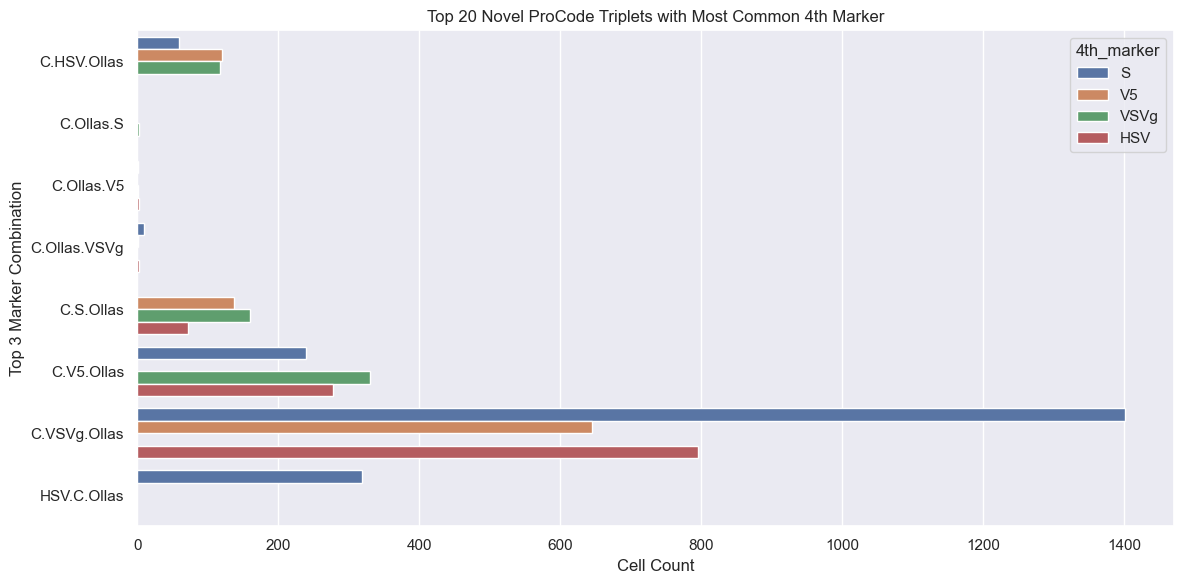

In [121]:
# Step 1: Flatten known Gene KO ProCodes
known_top3_combos = set()

for gene, combos in Gene_procode_dict.items():
    for combo in combos:
        combo_clean = combo.replace("-", "")  # match formatting
        known_top3_combos.add(combo_clean)

# Step 2: Compute summary without normalization and filter knowns
summary = (
    unassigned.groupby(["top3_combo", "4th_marker"])
    .size()
    .reset_index(name="count")
)

# Filter out known Gene KO triplets
summary_filtered = summary[~summary["top3_combo"].isin(known_top3_combos)].copy()

# Step 3: Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(
    data=summary_filtered.head(20), 
    y="top3_combo", 
    x="count", 
    hue="4th_marker"
)
plt.title("Top 20 Novel ProCode Triplets with Most Common 4th Marker")
plt.xlabel("Cell Count")
plt.ylabel("Top 3 Marker Combination")
plt.tight_layout()
plt.show()


In [122]:
summary

,top3_combo,4th_marker,count
0,C.HSV.Ollas,S,59
1,C.HSV.Ollas,V5,120
2,C.HSV.Ollas,VSVg,118
3,C.HSV.S,Ollas,46
4,C.HSV.S,V5,280
...,...,...,...
308,VSVg.V5.Ollas,HSV,44
309,VSVg.V5.Ollas,S,35
310,VSVg.V5.S,C,85
311,VSVg.V5.S,HSV,264


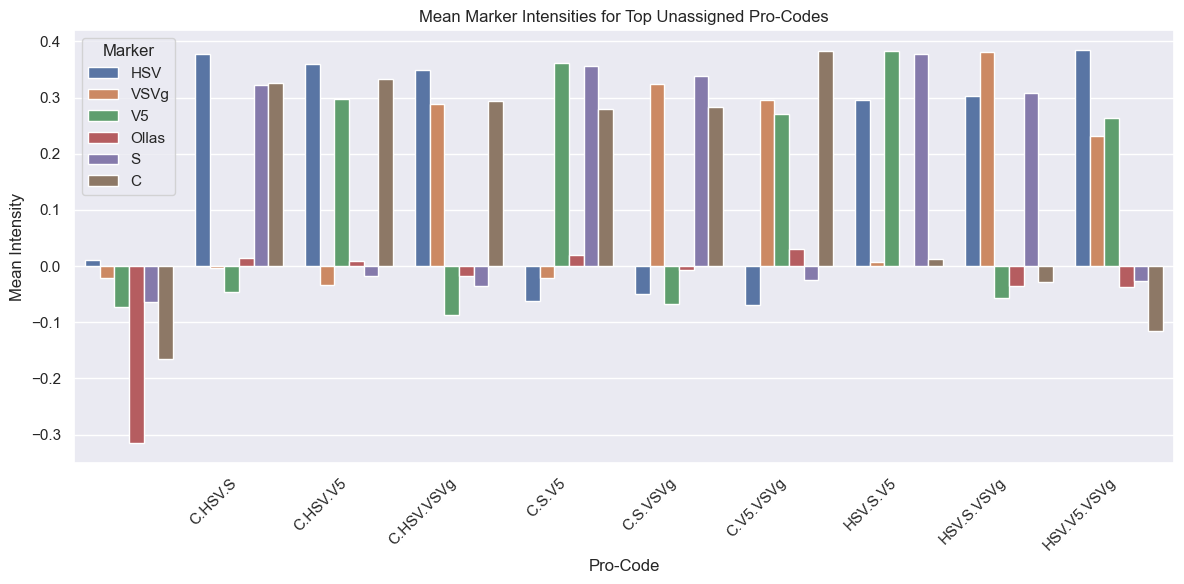

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

# Specify the marker columns used for Pro-Code calls
marker_cols = ['HSV', 'VSVg', 'V5', 'Ollas', 'S', 'C']

# Grab the top N "unknown" Pro-Code combos
top_unknowns = (
    df_merge[df_merge["Gene_KO"] == "Unknown"]["Pro-Code"]
    .value_counts()
    .head(10)
    .index.tolist()
)

# Subset data for just those combos
subset = df_merge[df_merge["Pro-Code"].isin(top_unknowns)].copy()
subset["Pro-Code"] = subset["Pro-Code"].astype(str)

# Compute the mean marker intensity per Pro-Code group
mean_marker_expr = (
    subset.groupby("Pro-Code")[marker_cols]
    .mean()
    .reset_index()
    .melt(id_vars="Pro-Code", var_name="Marker", value_name="Mean Intensity")
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=mean_marker_expr, x="Pro-Code", y="Mean Intensity", hue="Marker")
plt.xticks(rotation=45, ha='right')
plt.title("Mean Marker Intensities for Top Unassigned Pro-Codes")
plt.tight_layout()
plt.show()


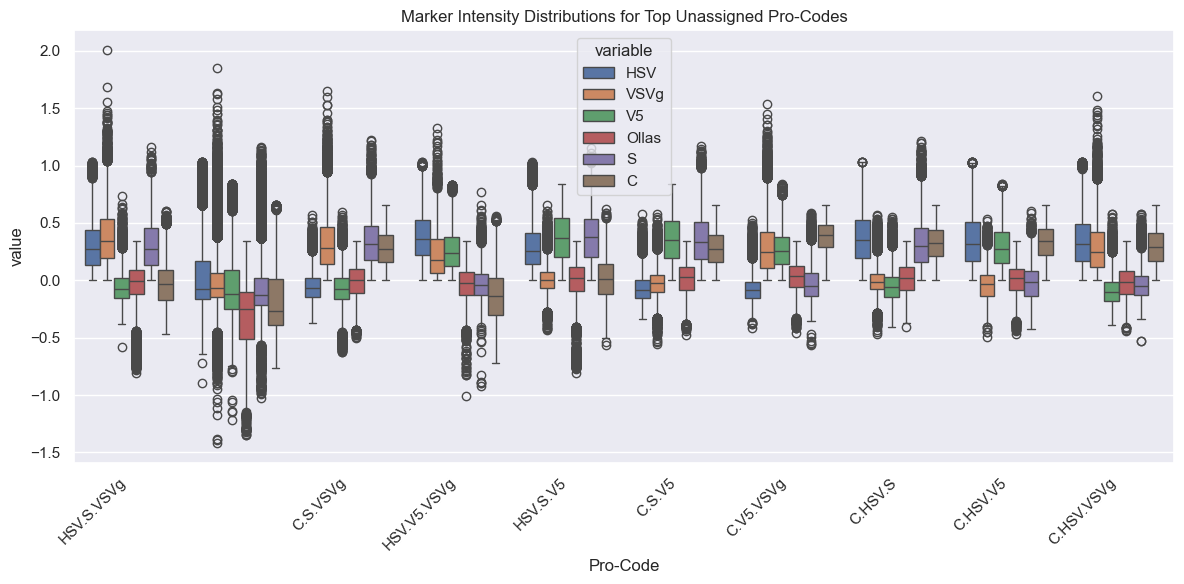

In [124]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=subset.melt(id_vars="Pro-Code", value_vars=marker_cols), 
            x="Pro-Code", y="value", hue="variable")
plt.xticks(rotation=45, ha='right')
plt.title("Marker Intensity Distributions for Top Unassigned Pro-Codes")
plt.tight_layout()
plt.show()


In [125]:
adata_nuc_filtered

AnnData object with n_obs × n_vars = 460937 × 12
    obs: 'cell_id', 'data_type', 'match_distance', 'Eccentricity', 'Solidity', 'MajorAxisLength', 'Area', 'Orientation', 'Extent', 'CellID', 'MinorAxisLength', 'x', 'y', 'imageid', 'Phenotype', 'Pro-Code', 'Normalized_Pro-Code', 'Gene_KO'
    var: 'protein_name', 'full_name', 'protein_type'
    uns: 'alignment_method', 'data_source', 'gates'
    obsm: 'spatial'

In [126]:
adata_cells.obs

,cell_id,data_type,match_distance,Eccentricity,Solidity,MajorAxisLength,Area,Orientation,Extent,CellID,MinorAxisLength,x,y,imageid,Phenotype
index_right,,,,,,,,,,,,,,,
aaaaakmp-1,aaaaakmp-1,cells,0.000000,0.532761,0.889128,9.239792,52.5,0.194728,0.676190,1.208720e+06,7.394007,958.353178,1894.690494,BDBAT0245,CD4 T cells
aaaabfpk-1,aaaabfpk-1,cells,0.031297,0.725308,0.930006,10.649834,58.0,-0.343453,0.628860,1.208785e+06,7.218797,956.271595,1929.507527,BDBAT0245,Tregs
aaaabmde-1,aaaabmde-1,cells,0.000000,0.834199,0.894737,16.977566,119.0,-0.246717,0.676136,1.208540e+06,9.362511,962.131142,1903.564643,BDBAT0245,Tregs
aaaagmle-1,aaaagmle-1,cells,0.000000,0.754994,0.922677,11.201065,64.0,0.759643,0.719792,1.208616e+06,7.356336,961.495784,1898.240218,BDBAT0245,Tregs
aaaahogc-1,aaaahogc-1,cells,0.000000,0.819421,0.723618,20.294309,144.0,0.651812,0.400000,1.206753e+06,11.632548,1017.830747,2030.934754,BDBAT0245,Myeloid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimhfgnl-1,oimhfgnl-1,cells,0.266035,0.871567,0.915663,24.522506,228.0,0.396411,0.647727,7.728980e+05,12.022794,2981.108965,10361.224733,BDBAT0245,Epithelial
oimhijei-1,oimhijei-1,cells,1.331654,0.528858,0.939394,15.311156,155.0,-0.408387,0.738095,7.728370e+05,12.994732,2987.208055,10388.208760,BDBAT0245,CD4 T cells
oimhjbde-1,oimhjbde-1,cells,1.906551,0.620552,0.917910,14.152859,123.0,-1.435683,0.745455,7.723120e+05,11.098182,3011.254642,10931.812998,BDBAT0245,Unknown


In [127]:
adata_nuc_filtered.obs

,cell_id,data_type,match_distance,Eccentricity,Solidity,MajorAxisLength,Area,Orientation,Extent,CellID,MinorAxisLength,x,y,imageid,Phenotype,Pro-Code,Normalized_Pro-Code,Gene_KO
index_right,,,,,,,,,,,,,,,,,,
aaaemadp-1,aaaemadp-1,nuclei,0.000000,0.789469,0.934211,12.252169,71.0,0.475597,0.657407,1201433.0,7.520270,1253.674264,2230.275037,BDBAT0245,Epithelial,HSV.S.VSVg,HSV.S.VSVg,Unknown
aaafmbll-1,aaafmbll-1,nuclei,0.000000,0.671399,0.915888,13.060135,98.0,-1.233659,0.685315,1203242.0,9.678813,1167.210875,2308.495895,BDBAT0245,Epithelial,,,Unknown
aaafpebp-1,aaafpebp-1,nuclei,0.000000,0.477531,0.847527,9.789506,61.5,0.723285,0.623737,1201864.0,8.421624,1232.007428,2334.321552,BDBAT0245,Epithelial,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
aaahdkjm-1,aaahdkjm-1,nuclei,0.000000,0.641862,0.910569,13.794317,112.0,-1.178506,0.666667,1202122.0,10.577760,1219.854904,2170.400387,BDBAT0245,Epithelial,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
aaajlelo-1,aaajlelo-1,nuclei,0.000000,0.448788,0.924300,9.541391,65.0,-0.250532,0.653409,1202324.5,8.443936,1211.956052,2090.327867,BDBAT0245,Epithelial,S.V5.VSVg,S.V5.VSVg,Rosa26_ctrl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimgeiii-1,oimgeiii-1,nuclei,0.365510,0.789175,0.792453,13.780355,84.0,0.839958,0.583333,768135.0,8.463460,3225.047635,9997.549758,BDBAT0245,Epithelial,,,Unknown
oimgigmf-1,oimgigmf-1,nuclei,0.000000,0.391397,0.894737,6.888753,34.0,-0.585952,0.693878,765157.0,6.339182,3378.230062,10642.981225,BDBAT0245,Epithelial,,,Unknown
oimheipl-1,oimheipl-1,nuclei,2.160185,0.866208,0.978261,10.653187,45.0,-0.029896,0.900000,773067.0,5.323228,2974.424310,10302.635020,BDBAT0245,Epithelial,,,Unknown


### Write new objects

In [128]:
adata_cells.write(f"cells.h5ad")

In [129]:
adata_nuc_filtered.write(f"procodes_final_annotated.h5ad")